<a href="https://colab.research.google.com/github/LucaBoni28/Alzheimer-Project_NeuroMaranello/blob/main/NeuroMaranelloNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT TITLE: Alzheimer’s Disease Detection with Deep Learning

## Group name: NeuroMaranello

### Group members:

* Luca Boninsegna YPOUBM

* Samuele Rosato YKQGE5

* Belarmino Gorlach-Lira N9Z4S5




---



## Package and Libraries installation

Installing the necessary modules

In [ ]:
!pip install pytorch-lightning --quiet
!pip install wandb --quiet
!pip install kagglehub --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 66.4 MB/s eta 0:00:00


Importing the necessary libs

In [ ]:
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch import nn
from torch.nn import functional as F
from torchmetrics.classification import Accuracy, Precision, Recall, F1Score
import torch
import torch.optim as optim
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar
import matplotlib.pyplot as plt
import os
from PIL import Image
import kagglehub
import cv2
import wandb
import pandas as pd
import numpy as np
import shutil
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from skimage.util import random_noise
import torchvision.models as models
from torchvision.models import ResNet18_Weights, VGG16_Weights, EfficientNet_B0_Weights

## Dataset Download

Downloading the Alzheimer's dataset from Kaggle (https://www.kaggle.com/datasets/marcopinamonti/alzheimer-mri-4-classes-dataset?resource=download)
and plotting one image for each class for sanity check

Using Colab cache for faster access to the 'augmented-alzheimer-mri-dataset' dataset.


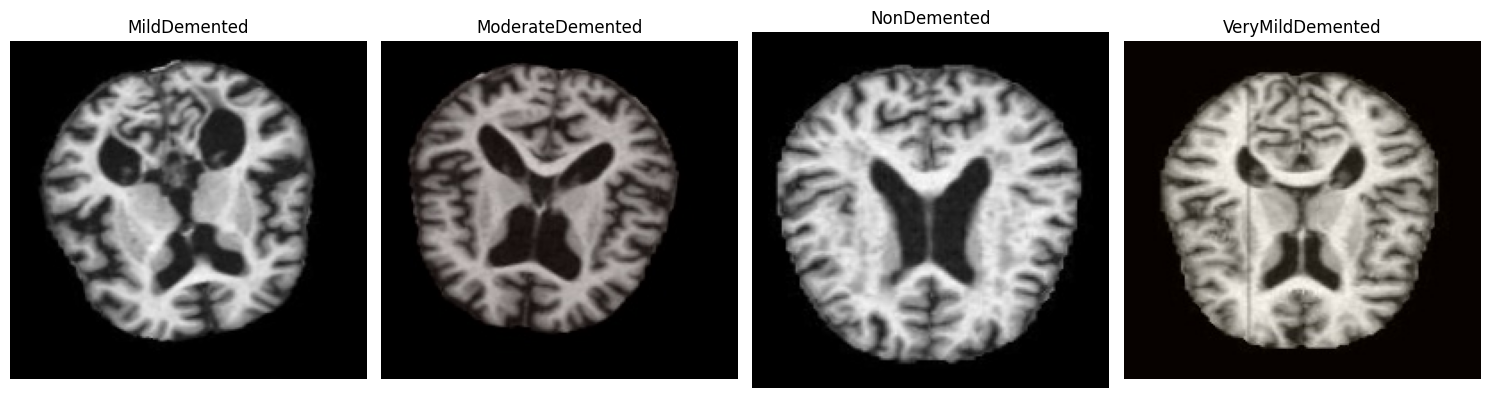

Contenuto cartella scaricata: ['OriginalDataset', 'AugmentedAlzheimerDataset']
Cartella selezionata come root: /kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset


In [ ]:
# Download the dataset
alzheimer_dataset = kagglehub.dataset_download("uraninjo/augmented-alzheimer-mri-dataset")

# Obtaining the root folder path
root_path = os.path.join(alzheimer_dataset, os.listdir(alzheimer_dataset)[1])

# Obtaining the class list
class_list = os.listdir(root_path)

# Sort class list for consistent plotting
class_list.sort()

# Plotting one image from each class for sanity check
plt.figure(figsize=(15, 5))
for i, class_name in enumerate(class_list):
    class_path = os.path.join(root_path, class_name)
    # Get the first image in the class directory
    image_filename = os.listdir(class_path)[4]
    image_path = os.path.join(class_path, image_filename)

    plt.subplot(1, len(class_list), i + 1)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Contenuto cartella scaricata:", os.listdir(alzheimer_dataset))
print("Cartella selezionata come root:",root_path)

## Encoding of the labels' classes

All the images are organized and labeled into their specific classes by encoding the labels' names with integer numbers as below:
* MildDemented -> 0
* ModerateDemented -> 1
* NonDemented -> 2
* VeryMildDemented -> 3

In [ ]:
# Creating the rows of data by matching images with their labels
rows = []
for label in sorted(class_list):
    label_dir = os.path.join(root_path, label)
    for img in os.listdir(label_dir):
        rows.append({"class_path": os.path.join(label_dir, img), "label": label})

# Creating the data frame with sorted values by label, and reseting the index
df = pd.DataFrame(rows).sort_values("label").reset_index(drop=True)

# Encode labels 0..3 and converts the names of the classes into numbers
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])

print("Class → index:", dict(zip(le.classes_, range(len(le.classes_)))))

Class → index: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


## Stratified K-fold technique implementation

The implementation of the Stratified K-Fold technique ensures every fold has the same ratio of classes between training and validation sets as the full dataset. This strategy should make a fairer training and validation division.

Moreover, since the initial dataset is very unbalanced and it doesn't have many images in total, we decided to divide the data into only training and validation sets, instead of the more standard division: training, validation and testing. Below is the visualization of the 3 generated folds.


In [ ]:
# We chose 3 folds
K = 3
X_idx = np.arange(len(df))
y = df["y"].to_numpy()

# Generating the 3 folds
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=70)

# Storing the validation and training indices for each fold
fold_indices = [(X_idx[tr], X_idx[va]) for tr, va in skf.split(X_idx, y)]
print(f"Prepared {len(fold_indices)} folds.")

def counts(arr):
    return dict(zip(le.classes_, np.bincount(arr, minlength=len(le.classes_))))

for i, (tr, va) in enumerate(fold_indices, start=1):
    print(f"\n=== Fold {i} ===")
    print("Train class counts:", counts(y[tr]))
    print("Val class counts:  ", counts(y[va]))



Prepared 3 folds.

=== Fold 1 ===
Train class counts: {'MildDemented': np.int64(5973), 'ModerateDemented': np.int64(4309), 'NonDemented': np.int64(6400), 'VeryMildDemented': np.int64(5974)}
Val class counts:   {'MildDemented': np.int64(2987), 'ModerateDemented': np.int64(2155), 'NonDemented': np.int64(3200), 'VeryMildDemented': np.int64(2986)}

=== Fold 2 ===
Train class counts: {'MildDemented': np.int64(5973), 'ModerateDemented': np.int64(4310), 'NonDemented': np.int64(6400), 'VeryMildDemented': np.int64(5973)}
Val class counts:   {'MildDemented': np.int64(2987), 'ModerateDemented': np.int64(2154), 'NonDemented': np.int64(3200), 'VeryMildDemented': np.int64(2987)}

=== Fold 3 ===
Train class counts: {'MildDemented': np.int64(5974), 'ModerateDemented': np.int64(4309), 'NonDemented': np.int64(6400), 'VeryMildDemented': np.int64(5973)}
Val class counts:   {'MildDemented': np.int64(2986), 'ModerateDemented': np.int64(2155), 'NonDemented': np.int64(3200), 'VeryMildDemented': np.int64(2987)

## Definition of the Alzheimer Data Module

In this section a class is defined to split the initial database into training and validation sets. In this class we selected two main solutions to mitigate the effect of the unbalanced dataset: class weights and a weighted sampler. For this version, we are using the class weights approach by setting the weighted sampler flag as False.

In [ ]:
# The class opens the image file at index(idx) row, apply a transform, and return one (image, label) pair.
# It'maps from an index to the corresponding pair (image, label).
class AlzheimerDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):     # Every time the dataloader gets a new image, it will access the dataframe with iloc and then this image will be transformed
        row = self.df.iloc[idx]
        img = Image.open(row["class_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["y"])
        return img, label     # The dataset will return the image and its label

Definition of the class to add salt and pepper noise

In [ ]:
class SaltPepperNoise(object):
    def __init__(self, amount=0.02):
        self.amount = amount

    def __call__(self, img_tensor):
        c, h, w = img_tensor.shape
        np_img = img_tensor.numpy()
        p_mask = np.random.rand(h, w)
        salt_mask = p_mask < (self.amount / 2.0)
        pepper_mask = (p_mask >= (self.amount / 2.0)) & (p_mask < self.amount)
        noisy_img = np_img.copy()
        noisy_img[:, salt_mask] = 1.0
        noisy_img[:, pepper_mask] = 0.0
        return torch.tensor(noisy_img, dtype=img_tensor.dtype)

Definition of the Data Module

In [ ]:
class AlzheimerDataModule(pl.LightningDataModule):
    def __init__(
        self,
        df,
        fold_indices,
        fold_id=0,
        batch_size=32,
        use_weighted_sampler=True     # Due to the unbalanced dataset
    ):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.fold_indices = fold_indices
        self.fold_id = int(fold_id)
        self.batch_size = batch_size
        self.use_weighted_sampler = use_weighted_sampler

        # Makes sure all images are same size (128x128), transforms them to tensors and normalizes
        self.transform = transforms.Compose([
            #transforms.CenterCrop((170,138)),
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.RandomApply([
                SaltPepperNoise(amount=0.02)      #salt and pepper augmentation
            ], p=0.5),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])

        # Gets the number of classes
        self.num_classes = int(self.df["y"].nunique())

    def setup(self, stage=None):
        train_idx, val_idx = self.fold_indices[self.fold_id]

        # Base dataset from df
        base_ds = AlzheimerDataset(self.df, transform=self.transform)

        # Creates a smaller dataset from the base dataset using our obtained training and validation indexes
        self.train_data = Subset(base_ds, train_idx)
        self.val_data   = Subset(base_ds, val_idx)

        # Computes the weights for each class based on the number of images, so the classes with less images have higher weight values
        train_labels = self.df.iloc[train_idx]["y"].to_numpy()
        classes = np.arange(self.num_classes)
        cw = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)

        # Increases the punishment of the model in case it fails to correctly label the class with less images, since we have less data to train on it
        self.class_weights = torch.tensor(cw, dtype=torch.float32)
        print(f"Class Weights: {self.class_weights.tolist()}")

        # We are applying a weighted sampler to increase the loading of the class with less images to try and make the training more balanced
        if self.use_weighted_sampler:
            class_counts = np.bincount(train_labels, minlength=self.num_classes)
            per_class_w = 1.0 / class_counts
            sample_w = per_class_w[train_labels]
            self.train_sampler = WeightedRandomSampler(
                weights=torch.tensor(sample_w, dtype=torch.double),
                num_samples=len(sample_w),
                replacement=True
            )
        else:
            self.train_sampler = None


    def train_dataloader(self):
        return DataLoader(
            self.train_data,
            batch_size=self.batch_size,
            shuffle=(self.train_sampler is None),     # In case there is no training sampler, we would shuffle the data
            sampler=self.train_sampler,               # However we are using a weighted sampler to try and increase the balance of the classes
            pin_memory=True                           # Optimizing the data transfer
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_data,
            batch_size=self.batch_size,
            shuffle=False,
            pin_memory=True
        )

This code is only for visualizing of the applied salt and pepper noise

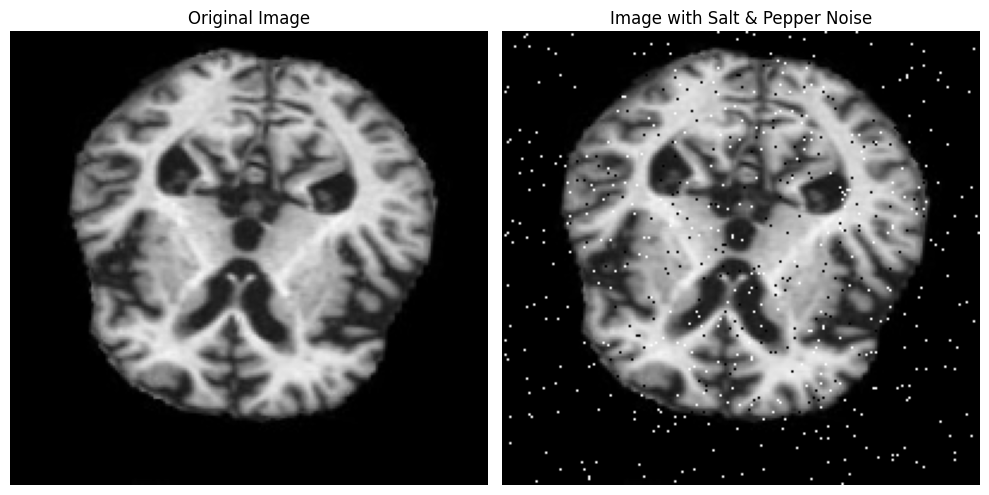

In [ ]:
example_image_path = df.iloc[0]['class_path']
original_img = Image.open(example_image_path).convert("RGB")

# Defining a transformation pipeline that includes resizing, ToTensor, and SaltPepper
salt_pepper_transform = transforms.Compose([
    transforms.ToTensor(),
    SaltPepperNoise(amount=0.02)
])

# Applying the transformation to get the augmented image
augmented_img_tensor = salt_pepper_transform(original_img)

# Convert the augmented tensor
augmented_img_np = augmented_img_tensor.permute(1, 2, 0).numpy()

# Plotting
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented_img_np)
plt.title('Image with Salt & Pepper Noise')
plt.axis('off')

plt.tight_layout()
plt.show()

## Definition of the Convolutional Neural Network (CNN)

For the definition of the CNN as a classifier we create a class that inherits from PyTorch Lightning Module.

List of the methods defined:
  * **init**: definition of the CNN and FC classifier architecture, the metrics accuracy, precision, recall and F1 score
  * **get_output_shape**: calculate the output size after all the convolution layers, which is used later as input size for the first FC layer
  * **feature_extractor**: how the convolution layers are applied. It's not mandatory, but it is used to keep the code more understandable
  * **forward**: calculate the output of the FC classifier starting from the features extracted by the CNN
  * **get_criterion**: define the Cross Entropy Loss as the cost function
  * **training_step**: method called for each batch to train the model returning the loss
  * **validation_step**: method called for each batch during the validation to check if the model is actually learning, but also not overfitting
  * **configure_optimizers**: selection of the optimizer

Definition of the LightningModule

In [ ]:
class AlzheimerLitModel(pl.LightningModule):
    def __init__(self, input_shape, num_classes, learning_rate=3e-4,
                 class_weights=None, neurons_fc1=512, neurons_fc2=128,
                 dropout_rate=0.5, optimizer_name='adam'):
        super().__init__()
        self.save_hyperparameters()

        in_channels = input_shape[0]

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(512)

        self.pool       = nn.MaxPool2d(2)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)

        self.global_pool = nn.AdaptiveAvgPool2d((6, 6))

        n_sizes = self._get_output_shape(input_shape)

        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc1 = nn.Linear(n_sizes, neurons_fc1)
        self.bn_fc1 = nn.BatchNorm1d(neurons_fc1)
        self.fc2 = nn.Linear(neurons_fc1, neurons_fc2)
        self.bn_fc2 = nn.BatchNorm1d(neurons_fc2)
        self.fc3 = nn.Linear(neurons_fc2, num_classes)

        if class_weights is not None:
            self.register_buffer('class_weights_buf',
                                 torch.tensor(class_weights, dtype=torch.float32))
        else:
            self.class_weights_buf = None

        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_f1 = F1Score(task="multiclass", num_classes=num_classes, average="macro")
        self.val_precision = Precision(task="multiclass", num_classes=num_classes, average="macro")
        self.val_recall = Recall(task="multiclass", num_classes=num_classes, average="macro")

    def _get_output_shape(self, shape):
        bs = 1
        x = torch.zeros(bs, *shape)
        with torch.no_grad():
            x = self.pool(self.leaky_relu(self.conv1(x)))
            x = self.pool(self.leaky_relu(self.conv2(x)))
            x = self.pool(self.leaky_relu(self.conv3(x)))
            x = self.leaky_relu(self.conv4(x))
            x = self.leaky_relu(self.conv5(x))
            x = self.global_pool(x)
        return x.view(bs, -1).size(1)

    def feature_extractor(self, x):
        x = self.pool(self.leaky_relu(self.bn1(self.conv1(x))))
        x = self.pool(self.leaky_relu(self.bn2(self.conv2(x))))
        x = self.pool(self.leaky_relu(self.bn3(self.conv3(x))))
        x = self.leaky_relu(self.bn4(self.conv4(x)))
        x = self.leaky_relu(self.bn5(self.conv5(x)))
        x = self.global_pool(x)
        return x

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.leaky_relu(self.bn_fc1(self.fc1(x))))
        x = self.dropout(self.leaky_relu(self.bn_fc2(self.fc2(x))))
        logits = self.fc3(x)
        return logits


    def _get_criterion(self):
        if self.class_weights_buf is not None:
            return nn.CrossEntropyLoss(weight=self.class_weights_buf)
        return nn.CrossEntropyLoss()

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self._get_criterion()(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.train_acc(preds, y)

        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self._get_criterion()(logits, y)
        preds = torch.argmax(logits, dim=1)

        self.val_acc(preds, y)
        self.val_f1(preds, y)
        self.val_precision(preds, y)
        self.val_recall(preds, y)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)
        self.log("val_f1", self.val_f1, prog_bar=True)
        self.log("val_prec", self.val_precision, prog_bar=True)
        self.log("val_rec", self.val_recall, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate, weight_decay=1e-5)
        return optimizer

# Hyperparameter Tuning

Then we configure sweeps to tune the hyperparameter values of learning rate, batch size, neurons in the 1st fully connected layer and dropout rate.

In [ ]:
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'min': 0.00001,
            'max': 0.001
        },
        'batch_size': {
            'values': [16, 32, 64]
        },
        'neurons_fc1': {
            'values': [256, 512, 128]
        },
        'dropout_rate': {
            'values': [0.3, 0.5, 0.7]
        },
    }
}

Since K-Fold is computationally expensive, we have decided not to run the full 3-Fold CV inside the sweep. This is an important part of the project's optimization strategy.

In [ ]:
def train_sweep():
    # 1. Initialize wandb
    wandb.init(project="NeuroMaranello-Alzheimer-Sweep")

    # 2. Get hyperparameters from wandb.config
    config = wandb.config

    # 3. Setup DataModule (Fixing seed for reproducibility in sweep comparison)
    data_module = AlzheimerDataModule(
        df=df,
        fold_indices=fold_indices,
        fold_id=0, # ONLY FOLD 0 USED FOR SWEEPING
        batch_size=config.batch_size,
        use_weighted_sampler=False
    )
    data_module.setup()

    # 4. Setup Model
    model = AlzheimerLitModel(
        input_shape=(3, 128, 128),
        num_classes=data_module.num_classes,
        learning_rate=config.learning_rate,
        class_weights=data_module.class_weights.cpu().numpy(),
        neurons_fc1=config.neurons_fc1,
        dropout_rate=config.dropout_rate
    )

    # 5. Setup Trainer
    checkpoint_callback = ModelCheckpoint(monitor="val_acc", mode="max")

    trainer = pl.Trainer(
        max_epochs=8,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        logger=WandbLogger(log_model=False),
        enable_progress_bar=False,
        callbacks=[checkpoint_callback]
    )

    # 6. Train
    trainer.fit(model, datamodule=data_module)

Tuning Hyperparameters

In [ ]:
wandb.login(key="49ccc34a17a2f2d6383f13935b576f8030bd8abc")
# 1. Initialize the sweep in WandB servers
sweep_id = wandb.sweep(sweep_config, project="NeuroMaranello-Alzheimer-Sweep")

# 2. Start the agent
wandb.agent(sweep_id, function=train_sweep, count=10)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: bgorlachlira (bgorlachlira-budapest-university-of-technology-and-economics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Create sweep with ID: cqfwdipg
Sweep URL: https://wandb.ai/bgorlachlira-budapest-university-of-technology-and-economics/NeuroMaranello-Alzheimer-Sweep/sweeps/cqfwdipg


wandb: Agent Starting Run: bdyhby7v with config:
wandb: 	batch_size: 32
wandb: 	dropout_rate: 0.7
wandb: 	learning_rate: 6.787470466215258e-05
wandb: 	neurons_fc1: 256


Class Weights: [0.9482672214508057, 1.3144581317901611, 0.8849999904632568, 0.9481084942817688]


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loggers/wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.


...

Class Weights: [0.9482672214508057, 1.3144581317901611, 0.8849999904632568, 0.9481084942817688]
Class Weights: [0.9482672214508057, 1.3144581317901611, 0.8849999904632568, 0.9481084942817688]


┏━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name          ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ conv1         │ Conv2d              │    896 │ train │     0 │
│ 1  │ bn1           │ BatchNorm2d         │     64 │ train │     0 │
│ 2  │ conv2         │ Conv2d              │ 18.5 K │ train │     0 │
│ 3  │ bn2           │ BatchNorm2d         │    128 │ train │     0 │
│ 4  │ conv3         │ Conv2d              │ 73.9 K │ train │     0 │
│ 5  │ bn3           │ BatchNorm2d         │    256 │ train │     0 │
│ 6  │ conv4         │ Conv2d              │  295 K │ train │     0 │
│ 7  │ bn4           │ BatchNorm2d         │    512 │ train │     0 │
│ 8  │ conv5         │ Conv2d              │  1.2 M │ train │     0 │
│ 9  │ bn5           │ BatchNorm2d         │  1.0 K │ train │     0 │
│ 10 │ pool          │ MaxPool2d           │      0 │ train │     0 │
│ 11 │ leaky_relu    │ LeakyReLU           │      0 │ train │     0 │
│ 12 │ global_pool   │ AdaptiveAvgPool2d   │      0 │ train │     0 │
│ 13 │ dropout       │ Dropout             │      0 │ train │     0 │
│ 14 │ fc1           │ Linear              │  2.4 M │ train │     0 │
│ 15 │ bn_fc1        │ BatchNorm1d         │    256 │ train │     0 │
│ 16 │ fc2           │ Linear              │ 16.5 K │ train │     0 │
│ 17 │ bn_fc2        │ BatchNorm1d         │    256 │ train │     0 │
│ 18 │ fc3           │ Linear              │    516 │ train │     0 │
│ 19 │ train_acc     │ MulticlassAccuracy  │      0 │ train │     0 │
│ 20 │ val_acc       │ MulticlassAccuracy  │      0 │ train │     0 │
│ 21 │ val_f1        │ MulticlassF1Score   │      0 │ train │     0 │
│ 22 │ val_precision │ MulticlassPrecision │      0 │ train │     0 │
│ 23 │ val_recall    │ MulticlassRecall    │      0 │ train │     0 │
└────┴───────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 3.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.9 M                                                                                                
Total estimated model params size (MB): 15                                                                         
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'neurons_fc1' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'dropout_rate' was locked by 'sweep' (ignored update).
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=8` reached.


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train_acc,▁▅▆▇▇███
train_loss,█▅▃▂▂▁▁▁
trainer/global_step,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
val_acc,▁▄▄▆▇▇██
val_f1,▁▃▄▆▇▇██
val_loss,█▆▅▃▂▂▁▁
val_prec,▁▅▅▆▇▇██
val_rec,▁▄▄▆▇▇██
epoch,7
train_acc,0.98106


Getting the best hyperparameters

In [ ]:
wandb.login(key="49ccc34a17a2f2d6383f13935b576f8030bd8abc")
# Initialize the W&B API
api = wandb.Api()

# Retrieve the sweep object
# Check if sweep_id is already defined (e.g., from a previous cell execution)
if 'sweep_id' not in globals():
    # If not defined, try to find the latest sweep for the project
    project_name = "NeuroMaranello-Alzheimer-Sweep"
    try:
        sweeps = api.project(project_name).sweeps()
        if sweeps:
            sweep_id = sweeps[0].id # Get the ID of the most recent sweep
            print(f"Sweep ID not found in current scope. Automatically retrieved latest sweep ID: {sweep_id}")
        else:
            raise ValueError(f"No sweeps found for project {project_name}. Please run the sweep initiation cell first.")
    except Exception as e:
        raise ValueError(f"Failed to retrieve sweep ID from W&B API: {e}. Please ensure you have run the sweep initiation cell that defines `sweep_id`.")

sweep_full_path = f"NeuroMaranello-Alzheimer-Sweep/{sweep_id}"
sweep = api.sweep(sweep_full_path)

# Get the best run according to the metric defined in sweep_config ('val_acc', 'maximize')
best_run = sweep.best_run()

print("------------------------------------------------")
print(f"Best Run ID: {best_run.id}")
print(f"Best Validation Accuracy: {best_run.summary.get('val_acc'):.4f}")
print("Best Hyperparameters:")
for key, val in best_run.config.items():
    print(f"   - {key}: {val}")
print("------------------------------------------------")

# Save best params to a dictionary for easy access
best_params = best_run.config

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


CommError: Could not find sweep <Sweep bgorlachlira-budapest-university-of-technology-and-economics/NeuroMaranello-Alzheimer-Sweep/dwgonn8r (Unknown State)>

*Actually we didnt't have time to solve this error, there was some issue with the code unable to find the correct sweep id, it appeared 30 min before the deadline, but the results are visible in the report.*

# CNN Training with validation

By looping through each previously defined k-fold we setup the AlzheimerDataModule, AlzheimerLitModel, the checkpoint_callback, the trainer and then we train the model and apply the validation after each epoch. Before starting the loop again for the next fold, we compare the current best model's accuracy with the absolute best value in order to find and save the model which has the absolute best validation accuracy value.

In [ ]:
# CLEANUP BEST_MODEL_FOLDER of PREVIOUS RUNS
# in order to avoid confusing the last run results, with previous runs
dirs_to_clean = ['best_our_model_folder']

print("--- Cleaning up old run artifacts ---")
for dir_path in dirs_to_clean:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
        print(f"Successfully removed old directory: {dir_path}")
    else:
        print(f"Directory not found (already clean): {dir_path}")
print("--- Cleanup complete. Starting new run. ---")

wandb.login()

# RUN THE TRAINING
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize variables to track the absolute best model across all folds
best_val_acc = 0.0
best_overall_model_path = None

for i in range(K):
  fold_id = i
  print(f"\n======= STARTING FOLD {fold_id + 1}/{K} =======")

  wandb_logger = WandbLogger(project="NeuroMaranello-Alzheimer",
                             name=f"k-fold-run-fold-{fold_id}",
                             group="K-fold-our-model")

  # Setup the data
  data_module = AlzheimerDataModule(
      df=df,
      fold_indices=fold_indices,
      fold_id=fold_id,
      batch_size=best_params['batch_size'],
      use_weighted_sampler=False # Putting false to test the weighted classes method instead of the weighted sampler
  )

  data_module.setup("fit")

  num_classes = data_module.num_classes

  # Parse the string representation of class_weights back into a numpy array
  parsed_class_weights = np.fromstring(best_params['class_weights'].strip('[]'), sep=' ')

  # Defining the model parameters
  model = AlzheimerLitModel(
      input_shape=(3, 128, 128),
      num_classes=num_classes,
      learning_rate=best_params['learning_rate'],
      neurons_fc1=best_params['neurons_fc1'],
      neurons_fc2=best_params['neurons_fc2'],
      dropout_rate=best_params['dropout_rate'],
      optimizer_name=best_params['optimizer_name'],
      class_weights=parsed_class_weights
  )

  checkpoint_callback = ModelCheckpoint(
          monitor="val_acc",
          mode="max",
          dirpath='best_our_model_folder',
          save_top_k=1,
          filename=f"best-our-model-fold-{fold_id}"
      )

  # Setting up the Trainer
  trainer = pl.Trainer(
      max_epochs=10,
      accelerator="gpu" if torch.cuda.is_available() else "cpu",
      logger=wandb_logger,
      log_every_n_steps=10,
      callbacks=[checkpoint_callback],
      deterministic=False
  )

  # Training the model
  trainer.fit(model, datamodule=data_module)

  # Loading the last best model from the call back for the current fold
  current_best_fold_model_path = checkpoint_callback.best_model_path
  current_best_fold_model = AlzheimerLitModel.load_from_checkpoint(current_best_fold_model_path, weights_only=False).to(device)

  # Evaluate the best model and save its validation accuracy in current_val_acc
  trainer.validate(current_best_fold_model, datamodule=data_module)
  current_val_acc = trainer.callback_metrics["val_acc"].item()

  print("\n======= BEFORE UPDATE ======")
  print(f"BEST overall: {best_val_acc}")
  print(f"Current Fold {fold_id} best: {current_val_acc}")

  # Updating the best model by comparing the best validation accuracy with the current loaded model
  if best_val_acc < current_val_acc:
    best_val_acc = current_val_acc
    best_overall_model_path = current_best_fold_model_path
  print("\n======= AFTER UPDATE ======")
  print(f"BEST overall: {best_val_acc}")

  # Finish the wandb run for the current fold
  wandb.finish()

Validation ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177/177 0:00:29 • 0:00:00 5.97it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.9559498429298401     │
│          val_f1           │    0.9591728448867798     │
│         val_loss          │    0.12116562575101852    │
│         val_prec          │    0.9590346813201904     │
│          val_rec          │    0.9596260786056519     │
└───────────────────────────┴───────────────────────────┘


======= BEFORE UPDATE ======
BEST overall: 0.9597457647323608
Current Fold 2 best: 0.9559498429298401

======= AFTER UPDATE ======
BEST overall: 0.9597457647323608


epoch,▁▁▂▂▂▂▃▃▄▄▅▅▅▅▆▆▇▇▇▇█
train_acc,▁▄▆▇▇█████
train_loss,█▅▄▂▂▁▁▁▁▁
trainer/global_step,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇███
val_acc,▁▄▆▄▇██▇███
val_f1,▁▅▇▄▇██▇███
val_loss,█▅▃▆▃▂▁▂▁▁▁
val_prec,▁▄▆▄▇▇█▇███
val_rec,▁▄▆▄▇██▇███
epoch,10
train_acc,0.98371


# Grad-CAM

Definition of the Grad-CAM class

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hook into the target layer (Forward and Backward)
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        self.model.eval()

        # Forward Pass
        logits = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(logits, dim=1)

        # Backward Pass
        self.model.zero_grad()
        target_score = logits[0, class_idx]
        target_score.backward()

        # Create Heatmap
        # Average the gradients (weights)
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        # Multiply weights by activations
        activation = self.activations[0]
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]

        # Average channels to create 2D heatmap
        heatmap = torch.mean(activation, dim=0).cpu().detach()

        # Apply ReLU (keep only positive influence)
        heatmap = F.relu(heatmap)

        # Normalize
        if torch.max(heatmap) > 0: # Avoid division by zero
            heatmap /= torch.max(heatmap)

        return heatmap.numpy()

Definition of the visualization function of the heatmap

In [ ]:
def show_gradcam_v2(heatmap, original_img_tensor, title="Grad-CAM"):
    # Denormalize using the CORRECT ImageNet stats
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])

    img = original_img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)

    # Resize heatmap to match image dimensions
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Create the heatmap color map
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_colored_bgr = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Convert BGR to RGB (Fixes Blue/Red swap)
    heatmap_colored_rgb = cv2.cvtColor(heatmap_colored_bgr, cv2.COLOR_BGR2RGB)
    heatmap_float = np.float32(heatmap_colored_rgb) / 255.0

    # Overlay
    superimposed = heatmap_float * 0.5 + img
    superimposed /= np.max(superimposed)

    # Plotting
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original MRI (Un-normalized)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Heatmap Only")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title(title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Execution of the heatmap visualization

In [ ]:
# Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlzheimerLitModel.load_from_checkpoint(best_overall_model_path, weights_only=False)
model.to(device)
model.eval()

target_layer = model.conv4

# Initialize Grad-CAM
grad_cam = GradCAM(model, target_layer)

# Get Data
data_iter = iter(data_module.val_dataloader())
images, labels = next(data_iter)

# Select an image
idx = 1
img_tensor = images[idx].unsqueeze(0).to(device)

# Run and Visualize
heatmap = grad_cam(img_tensor)

# Check if heatmap is empty
if np.max(heatmap) == 0:
    print("Warning: Heatmap is all zeros! The model found no positive features for this class.")
else:
    show_gradcam_v2(heatmap, images[idx], title=f"Grad-CAM")

AttributeError: 'NoneType' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

*This error is a consequence of the previous one*

# Conclusion

After training, validation and tuning, the results and evaluation show that the best validation accuracy, equal to 0.95, was obtained with the second fold. The overall developed model obtained a high performance.

# Advanced Task

Redifining the Data Module with a different normalization for the advanced task

In [ ]:
class AlzheimerDataModule(pl.LightningDataModule):
    def __init__(
        self,
        df,
        fold_indices,
        fold_id=0,
        batch_size=32,
        use_weighted_sampler=True
    ):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.fold_indices = fold_indices
        self.fold_id = int(fold_id)
        self.batch_size = batch_size
        self.use_weighted_sampler = use_weighted_sampler

        # Only the transform part needs to be modified for this evaluation
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)), # now the size became 224 due to the input size of ResNet
            transforms.ToTensor(),
            transforms.RandomApply([
                SaltPepperNoise(amount=0.02)
            ], p=0.5),
            # Changed to the standard normalization for Transfer Learning (ImageNet stats)
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        self.num_classes = int(self.df["y"].nunique())

    def setup(self, stage=None):
        train_idx, val_idx = self.fold_indices[self.fold_id]

        base_ds = AlzheimerDataset(self.df, transform=self.transform)

        self.train_data = Subset(base_ds, train_idx)
        self.val_data   = Subset(base_ds, val_idx)

        train_labels = self.df.iloc[train_idx]["y"].to_numpy()
        classes = np.arange(self.num_classes)
        cw = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)

        self.class_weights = torch.tensor(cw, dtype=torch.float32)
        print(f"Class Weights: {self.class_weights.tolist()}")

        if self.use_weighted_sampler:
            class_counts = np.bincount(train_labels, minlength=self.num_classes)
            per_class_w = 1.0 / class_counts
            sample_w = per_class_w[train_labels]
            self.train_sampler = WeightedRandomSampler(
                weights=torch.tensor(sample_w, dtype=torch.double),
                num_samples=len(sample_w),
                replacement=True
            )
        else:
            self.train_sampler = None


    def train_dataloader(self):
        return DataLoader(
            self.train_data,
            batch_size=self.batch_size,
            shuffle=(self.train_sampler is None),
            sampler=self.train_sampler,
            pin_memory=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_data,
            batch_size=self.batch_size,
            shuffle=False,
            pin_memory=True
        )

## Transfer Learning
Lightning Module modified to use another standard net with a pretrained backbone. The chosen network to be used was ResNet18

In [ ]:
class TransferLearningModel(pl.LightningModule):
    def __init__(self, input_shape, num_classes, model_name='resnet18', learning_rate=3e-4, #new variable model_name to selected the desired network
                 class_weights=None, neurons_fc1=512, neurons_fc2=128,
                 dropout_rate=0.5, optimizer_name='adam', freeze_backbone=False):
        super().__init__()
        self.save_hyperparameters()

        # Loading the pre-trained backbone
        self.feature_extractor = self._load_pretrained_model(model_name, freeze_backbone)

        # Automatically calculate the backbone output size
        dummy_input = torch.zeros(1, 3, 224, 224)
        with torch.no_grad():
            output_feat = self.feature_extractor(dummy_input)
            # Flatten the output to get the correct input size for the first FC layer
            n_sizes = output_feat.view(1, -1).size(1)

        # Classifier (Model Head) - Defined as individual layers now
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc1 = nn.Linear(n_sizes, neurons_fc1)
        self.bn_fc1 = nn.BatchNorm1d(neurons_fc1)
        self.fc2 = nn.Linear(neurons_fc1, neurons_fc2)
        self.bn_fc2 = nn.BatchNorm1d(neurons_fc2)
        self.fc3 = nn.Linear(neurons_fc2, num_classes) # Final layer for logits
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)

        # Class weights buffer
        if class_weights is not None:
            self.register_buffer('class_weights_buf', torch.tensor(class_weights, dtype=torch.float32))
        else:
            self.class_weights_buf = None

        # Metrics setup
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_f1 = F1Score(task="multiclass", num_classes=num_classes, average="macro")
        self.val_precision = Precision(task="multiclass", num_classes=num_classes, average="macro")
        self.val_recall = Recall(task="multiclass", num_classes=num_classes, average="macro")

        # Loads the model and removes the last classification layer
    def _load_pretrained_model(self, model_name, freeze):
        if model_name == 'resnet18':
            backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
            # Remove the final fully connected layer.
            layers = list(backbone.children())[:-2]
            feature_extractor = nn.Sequential(*layers)

        elif model_name == 'vgg16':
            backbone = models.vgg16(weights=VGG16_Weights.DEFAULT)
            feature_extractor = backbone.features
            # VGG's classifier head is separate, no need to remove layers with the list, feature_extractor.eval() is sufficient to remove the classification part implicitly.

        elif model_name == 'efficientnet_b0':
            backbone = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
            feature_extractor = backbone.features # EfficientNet features are a Sequential module

        else:
            raise ValueError(f"Model {model_name} not supported yet.")

        # FREEZING the weights
        if freeze:
            for param in feature_extractor.parameters():
                param.requires_grad = False

        return feature_extractor

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) # Flattening the feature_extractor output

        # Applying classifier layers explicitly
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.leaky_relu(x)

        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.leaky_relu(x)

        logits = self.fc3(x)
        return logits

    def _get_criterion(self):
        if self.class_weights_buf is not None:
            return nn.CrossEntropyLoss(weight=self.class_weights_buf)
        return nn.CrossEntropyLoss()

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self._get_criterion()(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.train_acc(preds, y)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self._get_criterion()(logits, y)
        preds = torch.argmax(logits, dim=1)

        self.val_acc(preds, y)
        self.val_f1(preds, y)
        self.val_precision(preds, y)
        self.val_recall(preds, y)

        self.log("val_acc", self.val_acc, prog_bar=True)
        self.log("val_rec", self.val_recall, prog_bar=True)
        return loss

    def configure_optimizers(self):
        # Adding L2 regularization with weight_decay(lambda)
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, self.parameters()),
                                     lr=self.hparams.learning_rate,
                                     weight_decay=1e-5)
        return optimizer

Definition of the traning function for the sweeps on the modified model

In [ ]:
def train_sweep():
    # Initialize wandb
    wandb.init(project="NeuroMaranello-Alzheimer-Sweep-Transfer")

    # Get hyperparameters from wandb.config
    config = wandb.config

    # Setup DataModule (Fixing seed for reproducibility in sweep comparison)
    data_module = AlzheimerDataModule(
        df=df,
        fold_indices=fold_indices,
        fold_id=0, # ONLY FOLD 0 FOR SWEEPING
        batch_size=config.batch_size,
        use_weighted_sampler=False
    )
    data_module.setup()

    # Setup Model
    model = TransferLearningModel(
        input_shape=(3, 128, 128),
        num_classes=data_module.num_classes,
        model_name='resnet18',
        freeze_backbone=True,
        learning_rate=config.learning_rate,
        class_weights=data_module.class_weights.cpu().numpy(),
        neurons_fc1=config.neurons_fc1,
        dropout_rate=config.dropout_rate
    )

    # Setup Trainer
    checkpoint_callback = ModelCheckpoint(monitor="val_acc", mode="max")

    trainer = pl.Trainer(
        max_epochs=6,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        logger=WandbLogger(log_model=False),
        enable_progress_bar=False,
        callbacks=[checkpoint_callback]
    )

    # Train
    trainer.fit(model, datamodule=data_module)

In [ ]:
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {
            'min': 0.00001,
            'max': 0.001
        },
        'batch_size': {
            'values': [16, 32, 64]
        },
        'neurons_fc1': {
            'values': [256, 512, 128]
        },
        'dropout_rate': {
            'values': [0.3, 0.5, 0.7]
        },
    }
}

In [ ]:
wandb.login(key="d749c7635959d33fa6977feff3ecee1ea5ff351e")
# Initialize the sweep in WandB servers
sweep_id = wandb.sweep(sweep_config, project="NeuroMaranello-Alzheimer-Sweep-Transfer")

# Start the agent
wandb.agent(sweep_id, function=train_sweep, count=6)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: samros11 (samros11-budapesti-m-szaki-s-gazdas-gtudom-nyi-egyetem) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Create sweep with ID: dwgonn8r
Sweep URL: https://wandb.ai/samros11-budapesti-m-szaki-s-gazdas-gtudom-nyi-egyetem/NeuroMaranello-Alzheimer-Sweep-Transfer/sweeps/dwgonn8r


wandb: Agent Starting Run: umm6xa4n with config:
wandb: 	batch_size: 16
wandb: 	dropout_rate: 0.5
wandb: 	learning_rate: 5.160357687612266e-05
wandb: 	neurons_fc1: 256


Class Weights: [0.9482672214508057, 1.3144581317901611, 0.8849999904632568, 0.9481084942817688]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 33.7MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loggers/wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.


...

Class Weights: [0.9482672214508057, 1.3144581317901611, 0.8849999904632568, 0.9481084942817688]


┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name              ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ feature_extractor │ Sequential          │ 11.2 M │ train │     0 │
│ 1  │ dropout           │ Dropout             │      0 │ train │     0 │
│ 2  │ fc1               │ Linear              │  6.4 M │ train │     0 │
│ 3  │ bn_fc1            │ BatchNorm1d         │    512 │ train │     0 │
│ 4  │ fc2               │ Linear              │ 32.9 K │ train │     0 │
│ 5  │ bn_fc2            │ BatchNorm1d         │    256 │ train │     0 │
│ 6  │ fc3               │ Linear              │    516 │ train │     0 │
│ 7  │ leaky_relu        │ LeakyReLU           │      0 │ train │     0 │
│ 8  │ train_acc         │ MulticlassAccuracy  │      0 │ train │     0 │
│ 9  │ val_acc           │ MulticlassAccuracy  │      0 │ train │     0 │
│ 10 │ val_f1            │ MulticlassF1Score   │      0 │ train │     0 │
│ 11 │ val_precision     │ MulticlassPrecision │      0 │ train │     0 │
│ 12 │ val_recall        │ MulticlassRecall    │      0 │ train │     0 │
└────┴───────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 6.5 M                                                                                            
Non-trainable params: 11.2 M                                                                                       
Total params: 17.6 M                                                                                               
Total estimated model params size (MB): 70                                                                         
Modules in train mode: 78                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

wandb: WARNING Config item 'learning_rate' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'neurons_fc1' was locked by 'sweep' (ignored update).
wandb: WARNING Config item 'dropout_rate' was locked by 'sweep' (ignored update).
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=6` reached.


epoch,▁▁▂▂▄▄▅▅▇▇██
train_acc,▁▅▆▇██
trainer/global_step,▁▁▂▂▄▄▅▅▇▇██
val_acc,▁▄▅▆▇█
val_rec,▁▄▅▆▇█
epoch,5
train_acc,0.71959
trainer/global_step,2123
val_acc,0.74382
val_rec,0.76013


In [ ]:
wandb.login(key="d749c7635959d33fa6977feff3ecee1ea5ff351e")
# Initialize the W&B API
api = wandb.Api()

# Retrieve the sweep object
# Check if sweep_id is already defined (e.g., from a previous cell execution)
if 'sweep_id' not in globals():
    # If not defined, try to find the latest sweep for the project
    project_name = "NeuroMaranello-Alzheimer-Sweep-Transfer"
    try:
        sweeps = api.project(project_name).sweeps()
        if sweeps:
            sweep_id = sweeps[0].id # Get the ID of the most recent sweep
            print(f"Sweep ID not found in current scope. Automatically retrieved latest sweep ID: {sweep_id}")
        else:
            raise ValueError(f"No sweeps found for project {project_name}. Please run the sweep initiation cell first.")
    except Exception as e:
        raise ValueError(f"Failed to retrieve sweep ID from W&B API: {e}. Please ensure you have run the sweep initiation cell that defines `sweep_id`.")

sweep_full_path = f"NeuroMaranello-Alzheimer-Sweep-Transfer/{sweep_id}"
sweep = api.sweep(sweep_full_path)

# Get the best run according to the metric defined in sweep_config ('val_acc', 'maximize')
best_run = sweep.best_run()

print("------------------------------------------------")
print(f"Best Run ID: {best_run.id}")
print(f"Best Validation Accuracy: {best_run.summary.get('val_acc'):.4f}")
print("Best Hyperparameters:")
for key, val in best_run.config.items():
    print(f"   - {key}: {val}")
print("------------------------------------------------")

# Save best params to a dictionary for easy access
best_params = best_run.config

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: samros11 (samros11-budapesti-m-szaki-s-gazdas-gtudom-nyi-egyetem) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Sweep ID not found in current scope. Automatically retrieved latest sweep ID: dwgonn8r


wandb: Sorting runs by -summary_metrics.val_acc


------------------------------------------------
Best Run ID: g3o3xe8x
Best Validation Accuracy: 0.7438
Best Hyperparameters:
   - batch_size: 64
   - model_name: resnet18
   - input_shape: [3, 128, 128]
   - neurons_fc1: 256
   - neurons_fc2: 128
   - num_classes: 4
   - dropout_rate: 0.3
   - class_weights: [0.9482672 1.3144581 0.885     0.9481085]
   - learning_rate: 0.0007769299372333604
   - optimizer_name: adam
   - freeze_backbone: True
------------------------------------------------


Training and Evaluation of the model on the 3 fold

In [ ]:
# CLEANUP BEST_MODEL_FOLDER of PREVIOUS RUNS
# in order to avoid confusing the last run results, with previous runs
dirs_to_clean = ['best_our_model_folder_transfer']

print("--- Cleaning up old run artifacts ---")
for dir_path in dirs_to_clean:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
        print(f"Successfully removed old directory: {dir_path}")
    else:
        print(f"Directory not found (already clean): {dir_path}")
print("--- Cleanup complete. Starting new run. ---")

wandb.login()

# RUN THE TRAINING
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize variables to track the absolute best model across all folds
best_val_acc = 0.0
best_overall_model_path = None

for i in range(K):
  fold_id = i
  print(f"\n======= STARTING FOLD {fold_id + 1}/{K} =======")

  wandb_logger = WandbLogger(project="NeuroMaranello-Alzheimer-Transfer",
                             name=f"k-fold-run-fold-{fold_id}",
                             group="K-fold-our-model")

  # Setup the data
  data_module = AlzheimerDataModule(
      df=df,
      fold_indices=fold_indices,
      fold_id=fold_id,
      batch_size=best_params['batch_size'],
      use_weighted_sampler=False # Putting false to test the weighted classes method instead of the weighted sampler
  )

  data_module.setup("fit")

  num_classes = data_module.num_classes

  # Parse the string representation of class_weights back into a numpy array
  parsed_class_weights = np.fromstring(best_params['class_weights'].strip('[]'), sep=' ')

  # Defining the model parameters
  model = TransferLearningModel(
      input_shape=(3, 128, 128),
      num_classes=num_classes,
      learning_rate=best_params['learning_rate'],
      neurons_fc1=best_params['neurons_fc1'],
      neurons_fc2=best_params['neurons_fc2'],
      dropout_rate=best_params['dropout_rate'],
      optimizer_name=best_params['optimizer_name'],
      class_weights=parsed_class_weights,
      freeze_backbone=True
  )

  checkpoint_callback = ModelCheckpoint(
          monitor="val_acc",
          mode="max",
          dirpath='best_our_model_folder_transfer',
          save_top_k=1,
          filename=f"best-our-model-fold-{fold_id}"
      )

  # Setting up the Trainer
  trainer = pl.Trainer(
      max_epochs=6,
      accelerator="gpu" if torch.cuda.is_available() else "cpu",
      logger=wandb_logger,
      log_every_n_steps=10,
      callbacks=[checkpoint_callback],
      deterministic=False
  )

  # Training the model
  trainer.fit(model, datamodule=data_module)

  # Loading the last best model from the call back for the current fold
  current_best_fold_model_path = checkpoint_callback.best_model_path
  current_best_fold_model = TransferLearningModel.load_from_checkpoint(current_best_fold_model_path, weights_only=False).to(device)

  # Evaluate the best model and save its validation accuracy in current_val_acc
  trainer.validate(current_best_fold_model, datamodule=data_module)
  current_val_acc = trainer.callback_metrics["val_acc"].item()

  print("\n======= BEFORE UPDATE ======")
  print(f"BEST overall: {best_val_acc}")
  print(f"Current Fold {fold_id} best: {current_val_acc}")

  # Updating the best model by comparing the best validation accuracy with the current loaded model
  if best_val_acc < current_val_acc:
    best_val_acc = current_val_acc
    best_overall_model_path_transfer = current_best_fold_model_path
  print("\n======= AFTER UPDATE ======")
  print(f"BEST overall: {best_val_acc}")

  # Finish the wandb run for the current fold
  wandb.finish()

--- Cleaning up old run artifacts ---
Directory not found (already clean): best_our_model_folder_transfer
--- Cleanup complete. Starting new run. ---

======= STARTING FOLD 1/3 =======
Class Weights: [0.9482672214508057, 1.3144581317901611, 0.8849999904632568, 0.9481084942817688]
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


Class Weights: [0.9482672214508057, 1.3144581317901611, 0.8849999904632568, 0.9481084942817688]


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name              ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ feature_extractor │ Sequential          │ 11.2 M │ train │     0 │
│ 1  │ dropout           │ Dropout             │      0 │ train │     0 │
│ 2  │ fc1               │ Linear              │  6.4 M │ train │     0 │
│ 3  │ bn_fc1            │ BatchNorm1d         │    512 │ train │     0 │
│ 4  │ fc2               │ Linear              │ 32.9 K │ train │     0 │
│ 5  │ bn_fc2            │ BatchNorm1d         │    256 │ train │     0 │
│ 6  │ fc3               │ Linear              │    516 │ train │     0 │
│ 7  │ leaky_relu        │ LeakyReLU           │      0 │ train │     0 │
│ 8  │ train_acc         │ MulticlassAccuracy  │      0 │ train │     0 │
│ 9  │ val_acc           │ MulticlassAccuracy  │      0 │ train │     0 │
│ 10 │ val_f1            │ MulticlassF1Score   │      0 │ train │     0 │
│ 11 │ val_precision     │ MulticlassPrecision │      0 │ train │     0 │
│ 12 │ val_recall        │ MulticlassRecall    │      0 │ train │     0 │
└────┴───────────────────┴─────────────────────┴────────┴───────┴───────┘

...

Output()

Class Weights: [0.9481084942817688, 1.3144581317901611, 0.8849999904632568, 0.9482672214508057]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.7403778433799744     │
│          val_rec          │    0.7561904191970825     │
└───────────────────────────┴───────────────────────────┘


======= BEFORE UPDATE ======
BEST overall: 0.7352577447891235
Current Fold 2 best: 0.7403778433799744

======= AFTER UPDATE ======
BEST overall: 0.7403778433799744


epoch,▁▁▂▂▃▃▅▅▆▆▇▇█
train_acc,▁▄▆▇██
trainer/global_step,▁▁▂▂▄▄▅▅▇▇███
val_acc,▁▃▅▆▇██
val_rec,▁▃▅▆▇██
epoch,6
train_acc,0.72007
trainer/global_step,2124
val_acc,0.74038
val_rec,0.75619


## Grad-CAM

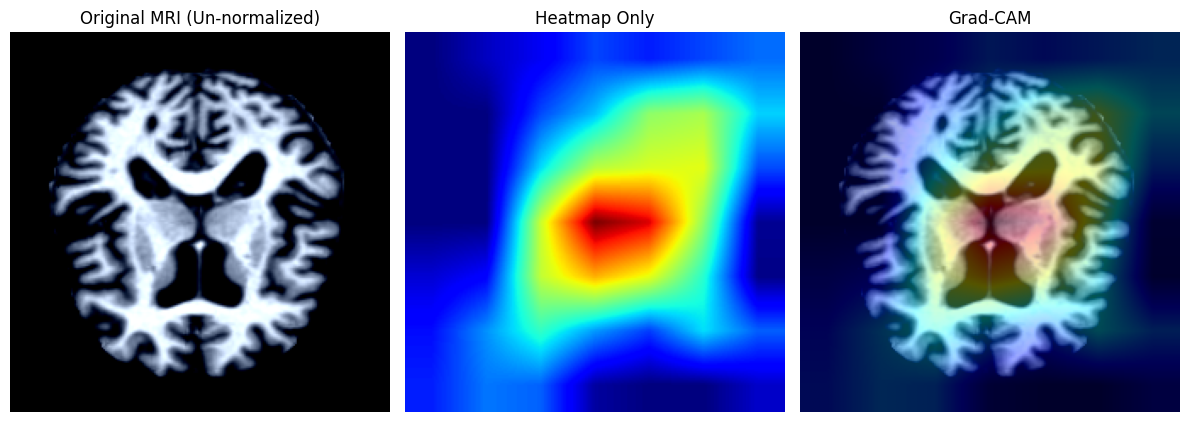

In [ ]:
# Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransferLearningModel.load_from_checkpoint(best_overall_model_path_transfer, weights_only=False)
model.to(device)
model.eval()

target_layer = model.feature_extractor[-1] # Changed for TransferLearningModel (ResNet18 layer4)

# Initialize Grad-CAM
grad_cam = GradCAM(model, target_layer)

# Get Data
data_iter = iter(data_module.val_dataloader())
images, labels = next(data_iter)

# Select an image
idx = 1
img_tensor = images[idx].unsqueeze(0).to(device)

# Crucial for Grad-CAM with a frozen backbone: make the input require gradients
img_tensor.requires_grad_(True)

# Run and Visualize
heatmap = grad_cam(img_tensor)

# Check if heatmap is empty
if np.max(heatmap) == 0:
    print("Warning: Heatmap is all zeros! The model found no positive features for this class.")
else:
    show_gradcam_v2(heatmap, images[idx], title=f"Grad-CAM")